# Forward model for DAS recorded amplitude 

In this notebook we use the travel time grids created in the previous on to forward model the amplitude recorded across a DAS array, from a point source, acounting for geometrical spreading.

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import pykonal 
from pykonal.transformations import geo2sph, sph2geo
import pandas as pd
from tqdm import tqdm
import glob
import re

from fct_DAS_sensitivity import *


## 1) Prepare each chanel information

Populate the CSV containing the channel location with the azimuth and the dip of the fiber <br>
The headers in the CSV file must be 'lat','lon' and 'depth' <br>

In [14]:
# datafram containing all the channels's location 
df = pd.read_csv(r'C:\Users\liliv\Desktop\Fagradalfjall\ttime_gid\All_channels\Channel_subset_Fagra.csv', index_col=0)
df = compute_azimuth_dip(df)
df.head()

,distance,Altitude,lon,lat,depth,azimuth,dip
Name,,,,,,,
0,0,79.449074,-22.314163,63.865142,-0.079449,296.940301,0.078616
17,68,79.541550,-22.312941,63.865416,-0.079542,274.057975,5.096457
25,100,82.375450,-22.312294,63.865436,-0.082375,255.990737,3.460152
37,148,85.254295,-22.311351,63.865332,-0.085254,235.883586,-2.880585
170,680,58.797287,-22.302457,63.862678,-0.058797,264.609716,-1.219012


## 2) Load data from travel time 

Point to the folders with the traveltime grids, but also the output folder. In it will be created a .CSV file containing amplitude informations. This file will be name as your 'file_name'.

In [15]:
# Path to the folder containing the travel time grids
folder = r'C:\Users\liliv\Desktop\DAS_senstivity\test'

# Path to the folder containing 
folder_out = r'C:\Users\liliv\Desktop\DAS_senstivity\Amplitude_test'

# Name of the output CSV 
file_name = 'Opa' 

## 3) Define your source

To define your source you must **locate** it using the class: <br>
* Location(latitude, longitude, depth) # °N, °E, km (sea level = 0, positif going down)

We created 3 classes of source for different applications : <br>
* **Homogeneous** : <br>

e = IsotropicSource(amplitude) <br>
* **Moment tensor** : <br>

e = MomentTensor(xx, xy, xz, yy, yz, zz)  <br>

* **Single force**: <br>

e = SingleForce(x, y, z) <br><br>
For all these source we only use the far field approximation of the orientation specific amplitude distribution of the energy around the source. 

In [20]:
# Locate your source in space 
loc = Location(63.906142,-22.3130629, 2) # lat, lon depth

# Describe the energy inside 
e = SingleForce(1, 1, 0) # (xx, yy, zz, xy, xz, yz)
#Create the source object 
source = SeismicSource("sweep_546", loc, e)

# Wave type to considerate in computation 
wave_type_list = ['P','SV', 'SH']


You can also plot the radiation pattern to make sure you have set correct parameters. See objecs_overview.ipynb for more plotting option

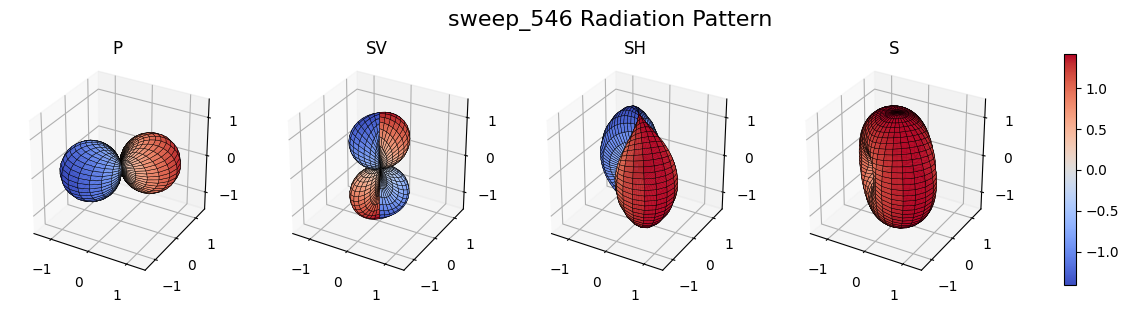

In [21]:
source.plot_radiation_pattern()

## 4) Error estimate

To have some estimate of your uncertunty, you can set an error on the receiver and the source. It will be evenly distributed across dip and azimuth. The error will be obtaine using Monte Carlo approach with 'MC_sample_number' of itteration using the error values as a perturbation.

In [22]:
# MC error hestimate
receiver_error = 3.55
source_error = 0.59
MC_sample_number = 100

## 5) Load model informations from $\delta$ travltime grids and verify source parameters

In [30]:
# Pykonal specific

latitudes = xr.load_dataarray(glob.glob(folder+'//*')[0]).coords['latitude'].values
longitudes = xr.load_dataarray(glob.glob(folder+'//*')[0]).coords['longitude'].values
depths = xr.load_dataarray(glob.glob(folder+'//*')[0]).coords['depth'].values

# node spacing
grid_spacing = (
    np.abs(depths[1] - depths[0]),
    np.deg2rad(np.abs(latitudes[1] - latitudes[0])),
    np.deg2rad(np.abs(longitudes[1] - longitudes[0])),)


# give the shape of your grid, here use the first grid of dataset and extract variable 
model_shape = xr.load_dataarray(glob.glob(folder+'/*')[0]).transpose( 'depth','latitude', 'longitude').values.shape


reference_point = geo2sph((latitudes.max(), longitudes.min(), depths.max()))

# Verify if source is in the model space
source_coord = np.array(geo2sph(source.location.values).squeeze())
max_coord = reference_point + (np.array(grid_spacing)*model_shape)
is_inside = np.all((source_coord >= reference_point) & (source_coord <= max_coord))

if is_inside:
    print('--------------------------------')
    print("Source is within the model space.")
    print('--------------------------------')
else:
    print('----------------------------------------')
    print("ERROR: Source is outside the model space!")
    print('----------------------------------------')
    dimensions = np.array(['depth', 'latitude', 'longitude'])
    for i, (s, mn, mx) in enumerate(zip(source_coord, reference_point, max_coord)):
        if not (mn <= s <= mx):
            print(f"  ➤ Dimension {dimensions[i]}: {s:.6f} not in [{mn:.6f}, {mx:.6f}]")

--------------------------------
Source is within the model space.
--------------------------------


## 6) create the model space

In [24]:
### Initialize the solver once with constant grid settings ###

solver = pykonal.solver.PointSourceSolver(coord_sys="spherical")
# Set up grid properties
solver.velocity.min_coords = reference_point
solver.velocity.node_intervals = grid_spacing
solver.velocity.npts = model_shape  # Ensure shape matches the travel time grid


# Create DataFrame to hold results 
result_container = pd.DataFrame()

# Create a list with all channel names to load travel times grids one after the other
all_files = glob.glob(folder+'//*')
number_only = [int(number.split('\\')[-1].split('.')[0]) for number in all_files]
number_only = sorted(number_only)

## 7) Run the model

In [25]:
for channel_name in tqdm(number_only):
      #try:
        ttime_path= folder+'\\'+str(channel_name)+'.h5'

        # extract the channel's specific informations 
        das = DASSensor(azimuth=df.loc[int(channel_name), 'azimuth'],
                        dip=df.loc[int(channel_name), 'dip'],
                        longitude = df.loc[int(channel_name), 'lon'],
                        latitude = df.loc[int(channel_name), 'lat'],
                        depth = df.loc[int(channel_name), 'depth'])
        
        # Load the travel time grid and assign it to the solver (check dimensions)
        ttimes = xr.load_dataarray(ttime_path)
        # Ensure the travel time grid is set correctly in the solver
        solver.tt.values = ttimes.transpose('depth', 'latitude', 'longitude').values  # Adjust dimensions if needed
        # trace ray 
        end = np.array(geo2sph(source.location.values).squeeze()) 
        ray = Ray(solver.trace_ray(end))
        
        # Pykonal returns a ray without the source and receiver node. We add them back in this line 
        # first node is at the DAS and last node at the source
        ray_nodes = np.vstack([np.array(geo2sph(das.values()).squeeze()),solver.trace_ray(end), end ])
        ray = Ray(ray_nodes)
        tt_source = solver.traveltime.value(end)

        # save ttime value
        result_container.loc[str(channel_name), 'ttime'] = tt_source 
        # get ray length in m
        ray_length = ray.length_spherical()*1000 # in m 

        #ray.plot_views()

        az_ray_DAS, dip_ray_DAS = ray.azimuth_and_dip('DAS', 50)
        az_ray_source, dip_ray_source = ray.azimuth_and_dip('source', 50)

        for wave_type in wave_type_list :

                # use MC sampling to get error on measure 
                MC_Channel_amplitude = np.zeros(MC_sample_numeber)

                MC_dip_fibre = np.random.normal(loc=dip_ray_DAS, scale=receiver_error/np.sqrt(2), size=MC_sample_numeber) #3.5/np.sqrt(2)
                MC_ray_azimuth_fibre = np.random.normal(loc=az_ray_DAS, scale=receiver_error/np.sqrt(2), size=MC_sample_numeber) #3.5/np.sqrt(2)
                
                MC_azimuth_source = np.random.normal(loc=az_ray_source, scale=source_error/np.sqrt(2), size=MC_sample_numeber) #3.5/np.sqrt(2)
                MC_colatitude_source = np.random.normal(loc=dip_ray_source, scale=source_error/np.sqrt(2), size=MC_sample_numeber) #3.5/np.sqrt(2)
                
                for MC_sample in range(MC_sample_numeber):
                
                        if MC_sample != 0:
                        
                                dip_ray_source = MC_colatitude_source[MC_sample]
                                az_ray_source = MC_azimuth_source [MC_sample]
                                
                                az_ray_DAS = MC_ray_azimuth_fibre[MC_sample]
                                dip_ray_DAS = MC_dip_fibre[MC_sample]
                        
                        ### STEP 1) Axial strain for the ray 
                        fiber_sensitivity = das.sensitivity(wave_type, az_ray_DAS, dip_ray_DAS)

                        ### STEP 2) Amplitude from the source mechanism
                        
                        FF_A = source.radiation_amplitude(az_ray_source, dip_ray_source, wave_type)
                        
                        ### step 3) assemple all 

                        phase_sensitivity = (fiber_sensitivity * FF_A) / ray_length

                        if wave_type != 'P':
                                # scale up S wave by 5 because amplitude ratio between S waves and P waves is alpha³ / beta ³
                                phase_sensitivity = phase_sensitivity*5

                        MC_Channel_amplitude[MC_sample] = phase_sensitivity
                        
                        if MC_sample ==0 :
                                result_container.loc[str(channel_name), str(wave_type)] = phase_sensitivity  

                result_container.loc[str(channel_name), 'error_'+str(wave_type)] = np.std(MC_Channel_amplitude)
                

                        
                        
result_container.to_csv(folder_out+'/'+file_name+'.csv')

  0%|          | 0/29 [00:00<?, ?it/s]

100%|██████████| 29/29 [00:07<00:00,  3.69it/s]
